# Deepfake / AI-vs-Real Image Detection — Training Notebook

**Goal:** train a strong, production-grade classifier that decides whether an image is **AI-generated** or **real**.

**Design choices (and why):**
- **EfficientNetV2-S** backbone (ImageNet transfer learning) — best accuracy/compute trade-off.
- **Two-stage training** — train the head first, then fine-tune the backbone at a low LR.
- **JPEG-compression augmentation** — stops the model cheating on compression fingerprints, forcing it to learn true generative cues (key for AI-detection).
- **Mixed precision + multi-GPU** — uses the Kaggle T4 x2 efficiently.
- **Rigorous evaluation** — ROC-AUC, PR-AUC, confusion matrix, calibration, threshold tuning.
- **Grad-CAM** — visualises *where* the model looks.

> Run top to bottom on Kaggle with **GPU T4 x2** and **Internet = On**.

## 1 · Setup, reproducibility & hardware

In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42
keras.utils.set_random_seed(SEED)

# Mixed precision -> uses the T4 tensor cores, ~2x faster, less memory
keras.mixed_precision.set_global_policy('mixed_float16')

# Use both GPUs if present (Kaggle T4 x2), else fall back to single device
gpus = tf.config.list_physical_devices('GPU')
strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()

print('TensorFlow :', tf.__version__)
print('GPUs       :', len(gpus))
print('Replicas   :', strategy.num_replicas_in_sync)
print('Precision  :', keras.mixed_precision.global_policy().name)

2026-06-25 14:56:23.529199: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782399383.796243      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782399383.859151      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782399384.471553      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782399384.471610      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782399384.471614      58 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow : 2.19.0
GPUs       : 2
Replicas   : 2
Precision  : mixed_float16


I0000 00:00:1782399399.484662      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782399399.487366      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 2 · Configuration

Everything you might tune lives here.

In [2]:
# ---- Locate dataset (folder that contains train.csv) -------------------
DATA_ROOT = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train.csv' in files:
        DATA_ROOT = root
        break
assert DATA_ROOT is not None, 'Could not find train.csv under /kaggle/input'
print('Dataset root:', DATA_ROOT)

# ---- Hyper-parameters --------------------------------------------------
IMG_SIZE   = 224          # input resolution
BATCH_SIZE = 64           # global batch (auto-split across GPUs)
AUTOTUNE   = tf.data.AUTOTUNE

EPOCHS_HEAD = 5           # stage 1: train head, backbone frozen
EPOCHS_FT   = 15          # stage 2: fine-tune backbone (early-stopped)
LR_HEAD     = 1e-3
LR_FT       = 1e-5

# Quick smoke test: set to an int like 4000 to train on a small subset first
SUBSET_N = None

# Which label value means AI / FAKE (verify with the image grid below)
FAKE_LABEL = 1

MODEL_DIR = '/kaggle/working'
os.makedirs(MODEL_DIR, exist_ok=True)

Dataset root: /kaggle/input/datasets/alessandrasala79/ai-vs-human-generated-dataset


## 3 · Data audit — columns, labels, balance, integrity

In [3]:
train_df = pd.read_csv(os.path.join(DATA_ROOT, 'train.csv'))
print('Shape  :', train_df.shape)
print('Columns:', train_df.columns.tolist())
print(train_df.head())

Shape  : (79950, 3)
Columns: ['Unnamed: 0', 'file_name', 'label']
   Unnamed: 0                                        file_name  label
0           0  train_data/a6dcb93f596a43249135678dfcfc17ea.jpg      1
1           1  train_data/041be3153810433ab146bc97d5af505c.jpg      0
2           2  train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg      1
3           3  train_data/8542fe161d9147be8e835e50c0de39cd.jpg      0
4           4  train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg      1


In [4]:
def _is_img(s):
    return str(s).lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))

# Auto-detect the filename column and the 0/1 label column
FILE_COL = next(c for c in train_df.columns
                if _is_img(train_df[c].dropna().astype(str).iloc[0]))
LABEL_COL = next(c for c in train_df.columns
                 if c != FILE_COL and train_df[c].dropna().nunique() == 2)
print('File column :', FILE_COL)
print('Label column:', LABEL_COL)

# If labels are strings (e.g. REAL / FAKE) map them to 0/1
if train_df[LABEL_COL].dtype == object:
    cats = sorted(train_df[LABEL_COL].dropna().unique())
    lmap = {cats[0]: 0, cats[1]: 1}
    train_df[LABEL_COL] = train_df[LABEL_COL].map(lmap)
    print('Mapped string labels ->', lmap)

# Work out how csv filenames map to real paths on disk
_s = str(train_df[FILE_COL].iloc[0])
if os.path.exists(os.path.join(DATA_ROOT, _s)):
    def to_path(f): return os.path.join(DATA_ROOT, str(f))
elif os.path.exists(os.path.join(DATA_ROOT, 'train_data', _s)):
    def to_path(f): return os.path.join(DATA_ROOT, 'train_data', str(f))
else:
    raise FileNotFoundError('Cannot resolve image paths; check folder layout')

print('Example path:', to_path(train_df[FILE_COL].iloc[0]))
print('Exists?     :', os.path.exists(to_path(train_df[FILE_COL].iloc[0])))

File column : file_name
Label column: label
Example path: /kaggle/input/datasets/alessandrasala79/ai-vs-human-generated-dataset/train_data/a6dcb93f596a43249135678dfcfc17ea.jpg
Exists?     : True


Label distribution:
label
0    39975
1    39975
Name: count, dtype: int64
Balance ratio: 1.0


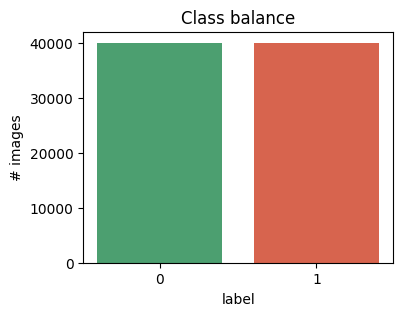

In [5]:
counts = train_df[LABEL_COL].value_counts().sort_index()
print('Label distribution:')
print(counts)
print('Balance ratio:', round(counts.min() / counts.max(), 3))

plt.figure(figsize=(4, 3))
plt.bar(counts.index.astype(str), counts.values, color=['#4C9F70', '#D7644E'])
plt.title('Class balance'); plt.xlabel('label'); plt.ylabel('# images')
plt.show()

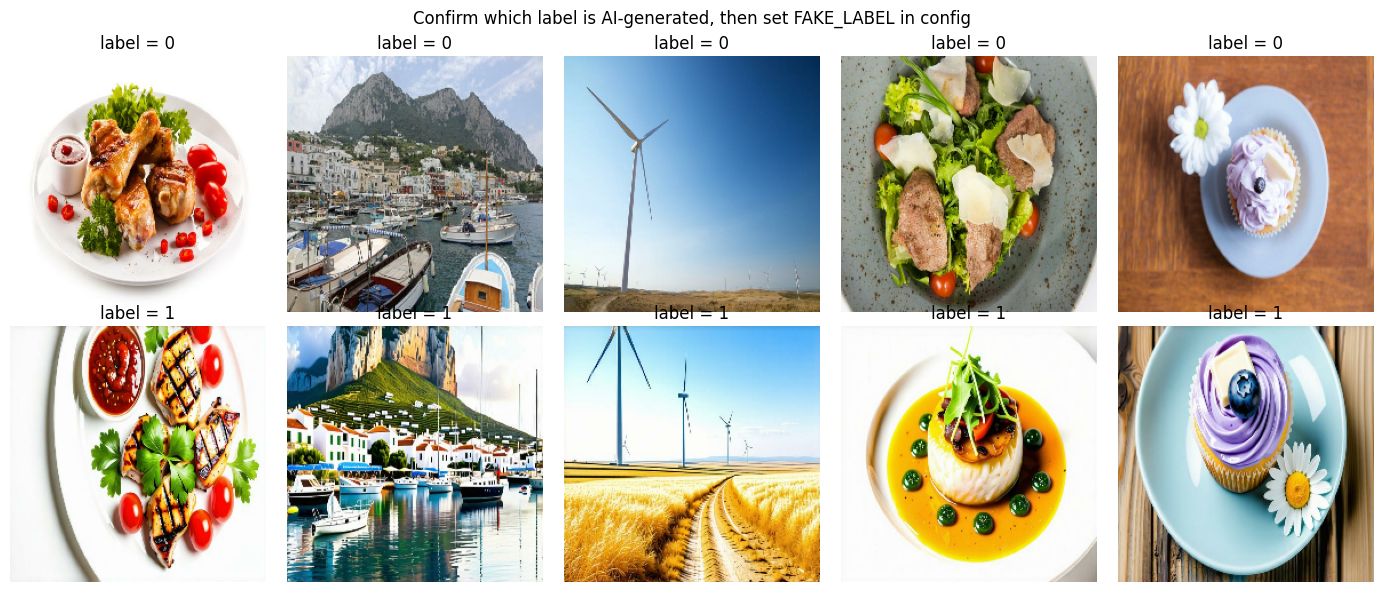

In [6]:
# Eyeball a few images per label so you can confirm which label is AI/FAKE.
def load_raw(path, size=IMG_SIZE):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, [size, size])
    return tf.cast(img, tf.uint8).numpy()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for r, lab in enumerate(sorted(train_df[LABEL_COL].unique())):
    sub = train_df[train_df[LABEL_COL] == lab].sample(5, random_state=SEED)
    for c, (_, row) in enumerate(sub.iterrows()):
        axes[r, c].imshow(load_raw(to_path(row[FILE_COL])))
        axes[r, c].axis('off')
        axes[r, c].set_title('label = ' + str(lab))
plt.suptitle('Confirm which label is AI-generated, then set FAKE_LABEL in config')
plt.tight_layout(); plt.show()

## 4 · Stratified train / val / test split (80 / 10 / 10)

We carve our own held-out test set from the labelled data so evaluation always has ground truth.

In [7]:
from sklearn.model_selection import train_test_split

df = train_df[[FILE_COL, LABEL_COL]].copy()
df['path']  = df[FILE_COL].map(to_path)
df['label'] = df[LABEL_COL].astype('float32')

if SUBSET_N is not None:
    df = df.groupby('label', group_keys=False).apply(
        lambda g: g.sample(min(len(g), SUBSET_N // 2), random_state=SEED))
    print('Using subset:', len(df), 'images')

train_df_, temp_df = train_test_split(
    df, test_size=0.20, stratify=df['label'], random_state=SEED)
val_df_, test_df_ = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print('Train:', len(train_df_))
print('Val  :', len(val_df_))
print('Test :', len(test_df_))

Train: 63960
Val  : 7995
Test : 7995


## 5 · Input pipeline + augmentation

Images stay in the **[0, 255]** range — EfficientNetV2 normalises internally.
The **random JPEG** step simulates real-world compression so the model learns genuine generative artifacts, not compression quirks.

In [8]:
def decode(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])     # -> float32 in [0,255]
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label

def random_jpeg(img, label):
    x = tf.image.convert_image_dtype(img / 255.0, tf.uint8)
    x = tf.image.random_jpeg_quality(x, 50, 100)
    x = tf.image.convert_image_dtype(x, tf.float32) * 255.0
    x.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return x, label

augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(0.10, value_range=[0, 255]),
    layers.RandomContrast(0.10),
], name='augment')

def make_ds(frame, training):
    ds = tf.data.Dataset.from_tensor_slices((frame['path'].values, frame['label'].values))
    if training:
        ds = ds.shuffle(4096, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(random_jpeg, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if training:
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_ds(train_df_, training=True)
val_ds   = make_ds(val_df_,   training=False)
test_ds  = make_ds(test_df_,  training=False)
print('Pipelines ready.')

Pipelines ready.


Batch: (64, 224, 224, 3) | range 0.0 - 255.0


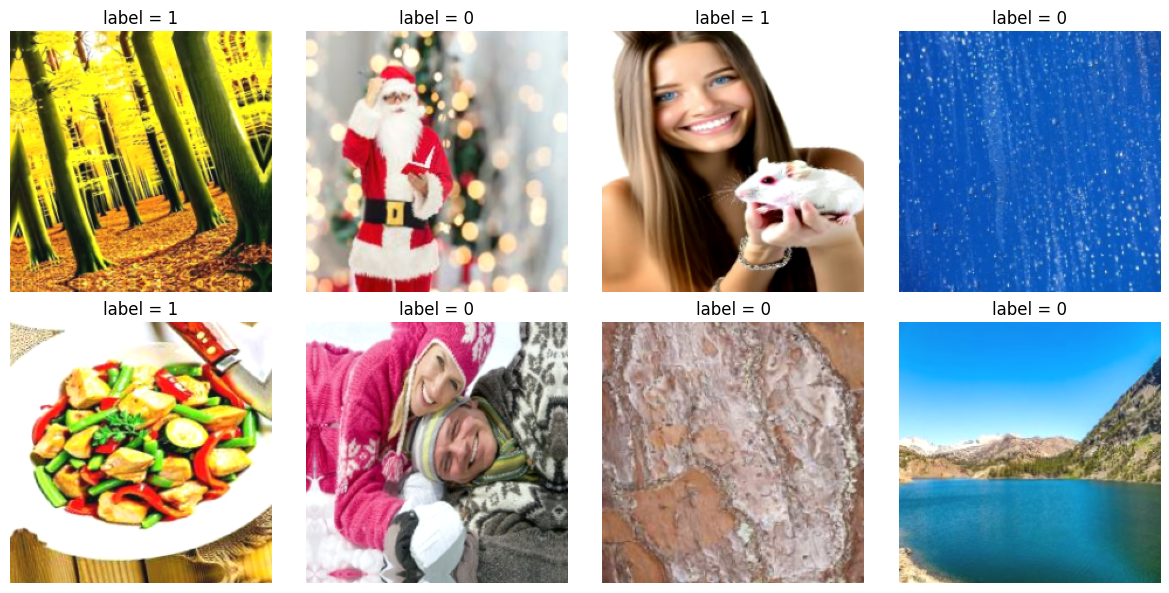

In [9]:
# Sanity check: look at one augmented batch
imgs, labs = next(iter(train_ds))
print('Batch:', imgs.shape, '| range', float(tf.reduce_min(imgs)), '-', float(tf.reduce_max(imgs)))

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(tf.cast(tf.clip_by_value(imgs[i], 0, 255), tf.uint8).numpy())
    plt.title('label = ' + str(int(labs[i]))); plt.axis('off')
plt.tight_layout(); plt.show()

## 6 · Model — EfficientNetV2-S transfer learning

Sigmoid output. We expose a separate **logits** layer so Grad-CAM gets clean (non-saturated) gradients later.

In [10]:
from tensorflow.keras.applications import EfficientNetV2S

def build_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = EfficientNetV2S(include_top=False, weights='imagenet',
                           input_tensor=inputs, include_preprocessing=True)
    base.trainable = False                              # stage 1: frozen backbone
    x = layers.GlobalAveragePooling2D(name='gap')(base.output)
    x = layers.Dropout(0.3, name='drop')(x)
    logits = layers.Dense(1, dtype='float32', name='logits')(x)
    prob   = layers.Activation('sigmoid', dtype='float32', name='prob')(logits)
    return keras.Model(inputs, prob, name='deepfake_effnetv2s'), base

with strategy.scope():
    model, base = build_model()
    model.compile(
        optimizer=keras.optimizers.Adam(LR_HEAD, clipnorm=1.0),   # clipnorm caps gradients -> prevents float16 NaN blow-ups
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics=['accuracy', keras.metrics.AUC(name='auc')])

model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "deepfake_effnetv2s"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        648 │ rescaling[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │         96 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      5,184 │ stem_activation[… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         96 │ block1a_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 112, 112,  │          0 │ block1a_project_… │
│                     │ 24)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 112, 112,  │      5,184 │ block1a_add[0][0] │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 112, 112,  │         96 │ block1b_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Dropout)           │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 112, 112,  │          0 │ block1b_drop[0][… │
│                     │ 24)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │     20,736 │ block1b_add[0][0] │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        384 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b

 Total params: 20,332,641 (77.56 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

## 7 · Stage 1 — train the head (backbone frozen)

In [11]:
from sklearn.utils.class_weight import compute_class_weight

w = compute_class_weight('balanced', classes=np.array([0.0, 1.0]),
                         y=train_df_['label'].values)
class_weight = {0: float(w[0]), 1: float(w[1])}
print('Class weights:', class_weight)

ckpt_path = os.path.join(MODEL_DIR, 'best_model.keras')
callbacks = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_auc', mode='max',
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=4,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    keras.callbacks.TerminateOnNaN(),   # belt-and-suspenders: stop instantly if loss ever goes NaN
]

hist_head = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
                      class_weight=class_weight, callbacks=callbacks)

Class weights: {0: 1.0, 1: 1.0}
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/devic

I0000 00:00:1782399548.319013     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782399548.319036     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.7540 - auc: 0.8332 - loss: 0.5256
Epoch 1: val_auc improved from None to 0.92178, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 719s 679ms/step - accuracy: 0.7940 - auc: 0.8772 - loss: 0.4766 - val_accuracy: 0.8108 - val_auc: 0.9218 - val_loss: 0.4449 - learning_rate: 0.0010
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.8187 - auc: 0.8995 - loss: 0.4400
Epoch 2: val_auc improved from 0.92178 to 0.92586, saving model to /kaggle/working/best_model.keras

Epoch 2: finished saving model to /kaggle/working/best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 537s 536ms/step - accuracy: 0.8199 - auc: 0.9010 - loss: 0.4376 - val_accuracy: 0.8185 - val_auc: 0.9259 - val_loss: 0.4326 - learning_rate: 0.0010
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.8245 - auc: 0.9051 - loss: 0.4307
Epoch 3: v

## 8 · Stage 2 — fine-tune the backbone (low LR)

In [12]:
base.trainable = True                                   # unfreeze backbone

with strategy.scope():
    model.compile(
        optimizer=keras.optimizers.Adam(LR_FT, clipnorm=1.0),   # clipnorm caps gradients -> prevents float16 NaN blow-ups
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics=['accuracy', keras.metrics.AUC(name='auc')])

print('Trainable weight tensors:', len(model.trainable_weights))

ft_callbacks = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_auc', mode='max',
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=3,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    keras.callbacks.TerminateOnNaN(),   # belt-and-suspenders: stop instantly if loss ever goes NaN
]

hist_ft = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT,
                    class_weight=class_weight, callbacks=ft_callbacks)

Trainable weight tensors: 452
Epoch 1/15
INFO:tensorflow:Collective all_reduce tensors: 452 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.8547 - auc: 0.9324 - loss: 0.3849
Epoch 1: val_auc improved from None to 0.98423, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 898s 739ms/step - accuracy: 0.8980 - auc: 0.9645 - loss: 0.3172 - val_accuracy: 0.9011 - val_auc: 0.9842 - val_loss: 0.3093 - learning_rate: 1.0000e-05
Epoch 2/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.9444 - auc: 0.9876 - loss: 0.2419
Epoch 2: val_auc improved from 0.98423 to 0.99118, saving model to /kaggle/working/best_model.keras

Epoch 2: finished saving model to /kaggle/working/best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 709s 706ms/step - accuracy: 0.9494 - auc: 0.9894 - lo

## 9 · Training curves

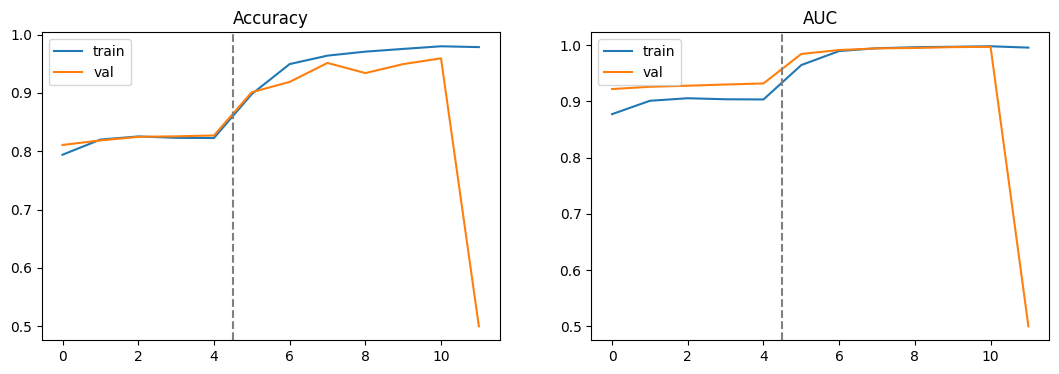

In [13]:
def merge(k):
    return hist_head.history.get(k, []) + hist_ft.history.get(k, [])

split = len(hist_head.history.get('accuracy', []))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(merge('accuracy'), label='train'); ax[0].plot(merge('val_accuracy'), label='val')
ax[0].axvline(split - 0.5, ls='--', c='gray'); ax[0].set_title('Accuracy'); ax[0].legend()
ax[1].plot(merge('auc'), label='train'); ax[1].plot(merge('val_auc'), label='val')
ax[1].axvline(split - 0.5, ls='--', c='gray'); ax[1].set_title('AUC'); ax[1].legend()
plt.show()

## 10 · Evaluation on the held-out test set

In [14]:
# Reload the best checkpoint (best validation AUC)
model = keras.models.load_model(ckpt_path)

y_true = test_df_['label'].values.astype(int)
y_prob = model.predict(test_ds, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 300ms/step


In [15]:
from sklearn.metrics import (accuracy_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report, brier_score_loss)

print('Accuracy :', round(accuracy_score(y_true, y_pred), 4))
print('ROC-AUC  :', round(roc_auc_score(y_true, y_prob), 4))
print('PR-AUC   :', round(average_precision_score(y_true, y_prob), 4))
print('Brier    :', round(brier_score_loss(y_true, y_prob), 4), '(lower = better calibrated)')
print()
print(classification_report(y_true, y_pred, target_names=['label 0', 'label 1']))

Accuracy : 0.9572
ROC-AUC  : 0.9973
PR-AUC   : 0.9974
Brier    : 0.0332 (lower = better calibrated)

              precision    recall  f1-score   support

     label 0       0.99      0.92      0.96      3998
     label 1       0.93      0.99      0.96      3997

    accuracy                           0.96      7995
   macro avg       0.96      0.96      0.96      7995
weighted avg       0.96      0.96      0.96      7995



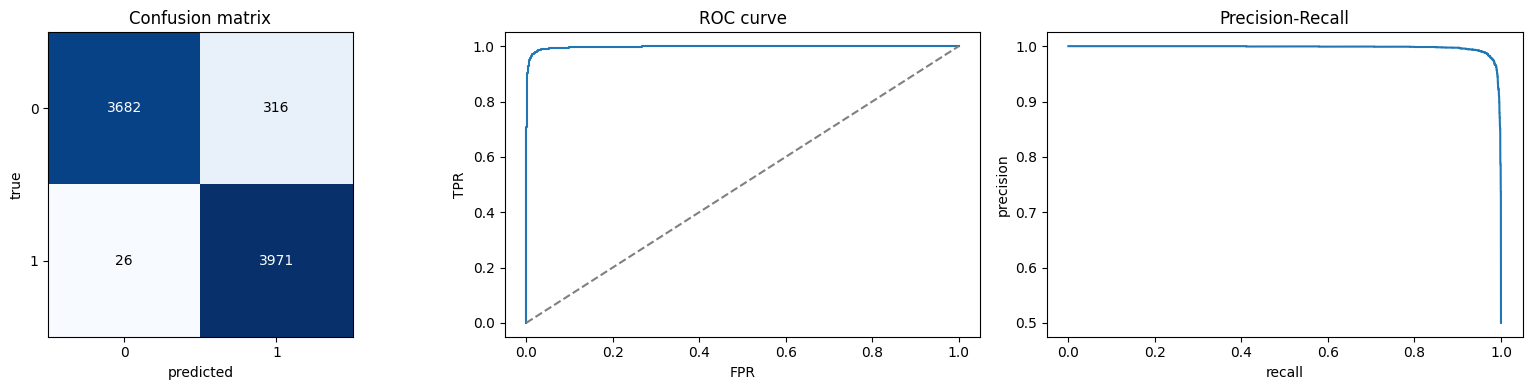

In [16]:
from sklearn.metrics import roc_curve, precision_recall_curve

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].imshow(cm, cmap='Blues'); ax[0].set_title('Confusion matrix')
ax[0].set_xticks([0, 1]); ax[0].set_yticks([0, 1])
ax[0].set_xlabel('predicted'); ax[0].set_ylabel('true')
for (i, j), v in np.ndenumerate(cm):
    ax[0].text(j, i, str(v), ha='center', va='center',
               color='white' if v > cm.max() / 2 else 'black')

fpr, tpr, _ = roc_curve(y_true, y_prob)
ax[1].plot(fpr, tpr); ax[1].plot([0, 1], [0, 1], '--', c='gray')
ax[1].set_title('ROC curve'); ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR')

prec, rec, _ = precision_recall_curve(y_true, y_prob)
ax[2].plot(rec, prec); ax[2].set_title('Precision-Recall')
ax[2].set_xlabel('recall'); ax[2].set_ylabel('precision')
plt.tight_layout(); plt.show()

Best F1 threshold: 0.757
Accuracy @ best  : 0.9786


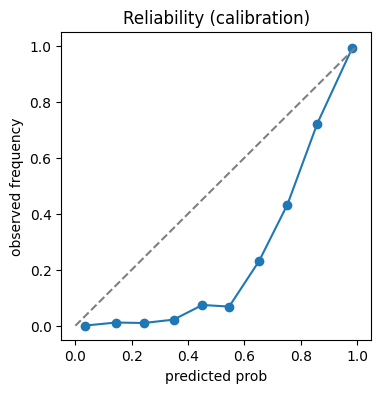

In [17]:
from sklearn.calibration import calibration_curve

# Tune the decision threshold for best F1
prec, rec, thr = precision_recall_curve(y_true, y_prob)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_t = float(thr[np.argmax(f1[:-1])])
print('Best F1 threshold:', round(best_t, 3))
print('Accuracy @ best  :', round(accuracy_score(y_true, (y_prob >= best_t).astype(int)), 4))

frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)
plt.figure(figsize=(4, 4))
plt.plot(mean_pred, frac_pos, marker='o'); plt.plot([0, 1], [0, 1], '--', c='gray')
plt.title('Reliability (calibration)')
plt.xlabel('predicted prob'); plt.ylabel('observed frequency')
plt.show()

## 11 · Grad-CAM — what is the model looking at?

Heatmaps over the last conv feature map, computed from the **logits** so gradients do not vanish through the sigmoid.

In [18]:
def find_last_conv(m):
    try:
        m.get_layer('top_activation'); return 'top_activation'
    except Exception:
        for layer in reversed(m.layers):
            try:
                if len(layer.output.shape) == 4:
                    return layer.name
            except Exception:
                pass
    raise ValueError('No 4-D conv layer found')

LAST_CONV = find_last_conv(model)
print('Grad-CAM layer:', LAST_CONV)

grad_model = keras.Model(
    model.inputs,
    [model.get_layer(LAST_CONV).output, model.get_layer('logits').output])

def grad_cam(img_batch):
    x = tf.cast(img_batch, tf.float32)
    with tf.GradientTape() as tape:
        conv_out, logit = grad_model(x, training=False)
        score = logit[:, 0]
    grads = tf.cast(tape.gradient(score, conv_out), tf.float32)
    conv_out = tf.cast(conv_out, tf.float32)
    weights = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.reduce_sum(conv_out * weights[:, None, None, :], axis=-1)
    cam = tf.maximum(cam, 0)
    cam = cam / (tf.reduce_max(cam, axis=(1, 2), keepdims=True) + 1e-9)
    return cam.numpy()

Grad-CAM layer: top_activation


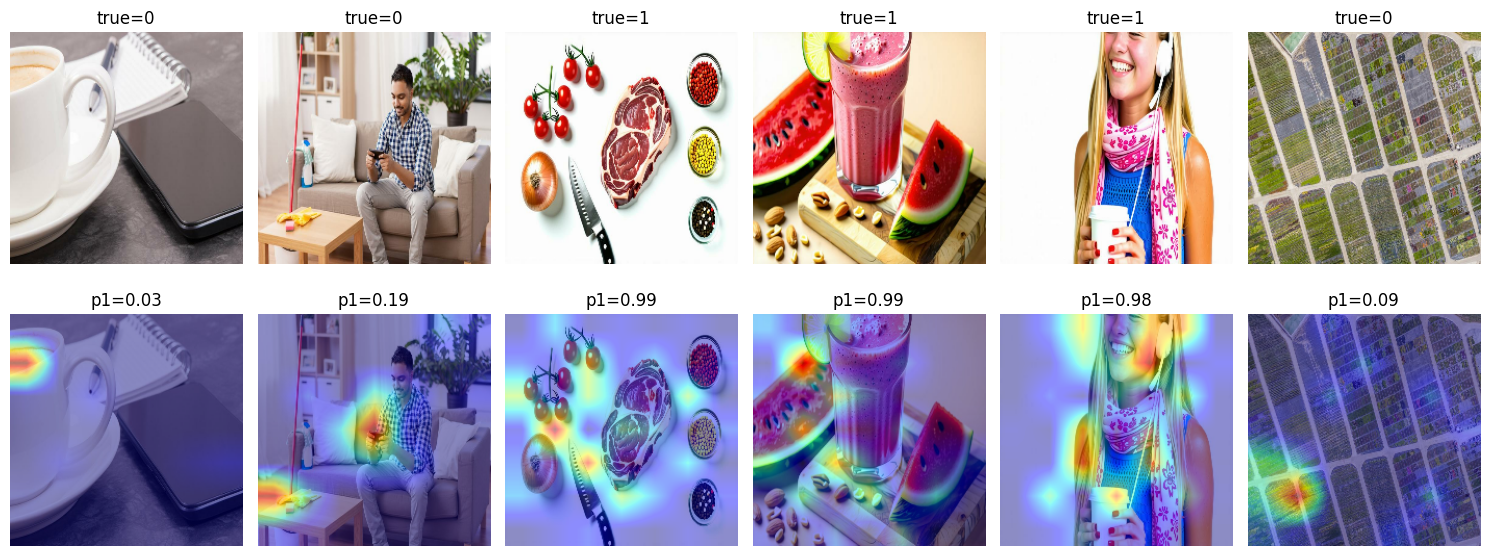

In [19]:
sample = test_df_.sample(6, random_state=SEED).reset_index(drop=True)
paths  = [str(p) for p in sample['path'].values]
labels = sample['label'].astype(int).tolist()
batch  = tf.stack([decode(p, 0)[0] for p in paths])
cams   = grad_cam(batch)
probs  = model.predict(batch, verbose=0).ravel()

plt.figure(figsize=(15, 6))
for i in range(len(paths)):
    img  = tf.cast(tf.clip_by_value(batch[i], 0, 255), tf.uint8).numpy()
    heat = tf.image.resize(cams[i][..., None], [IMG_SIZE, IMG_SIZE]).numpy()[..., 0]
    plt.subplot(2, 6, i + 1)
    plt.imshow(img); plt.axis('off'); plt.title('true=' + str(labels[i]))
    plt.subplot(2, 6, i + 7)
    plt.imshow(img); plt.imshow(heat, cmap='jet', alpha=0.45); plt.axis('off')
    plt.title('p1=' + format(probs[i], '.2f'))
plt.tight_layout(); plt.show()

## 12 · Export the model + metadata

Download `deepfake_effnetv2s.keras` and `model_meta.json` from the **Output** panel on the right.

In [20]:
final_path = os.path.join(MODEL_DIR, 'deepfake_effnetv2s.keras')
model.save(final_path)

meta = {
    'img_size': IMG_SIZE,
    'preprocessing': 'resize to img_size, keep pixels in [0,255] (model normalises internally)',
    'output': 'sigmoid probability that label == 1',
    'fake_label': FAKE_LABEL,
    'decision_threshold': best_t,
    'test_accuracy': float(accuracy_score(y_true, y_pred)),
    'test_roc_auc': float(roc_auc_score(y_true, y_prob)),
}
with open(os.path.join(MODEL_DIR, 'model_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
print(' ', final_path)
print(' ', os.path.join(MODEL_DIR, 'model_meta.json'))

Saved:
  /kaggle/working/deepfake_effnetv2s.keras
  /kaggle/working/model_meta.json


## 13 · Inference function (mirrors training preprocessing exactly)

This is the function to port into `app.py`. It resizes and feeds **[0, 255]** pixels — identical to training. (The old code applied ELA at inference but not during training; that mismatch is gone.)

In [21]:
def predict_image(path):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.expand_dims(img, 0)                         # [1,H,W,3] in [0,255]
    p1 = float(model.predict(img, verbose=0).ravel()[0])  # P(label == 1)
    p_fake = p1 if FAKE_LABEL == 1 else 1.0 - p1
    return {'p_fake': round(p_fake, 4),
            'verdict': 'AI / FAKE' if p_fake >= 0.5 else 'REAL'}

for p in test_df_['path'].sample(5, random_state=1).values:
    print(predict_image(str(p)), '<-', os.path.basename(str(p)))

{'p_fake': 0.9947, 'verdict': 'AI / FAKE'} <- 2badbb163933422aa5482c8371543b1f.jpg
{'p_fake': 0.9712, 'verdict': 'AI / FAKE'} <- 86718f1d94dc4baeb4e03e5aedbf88e9.jpg
{'p_fake': 0.0419, 'verdict': 'REAL'} <- 6702b797a7784063861992601f396c88.jpg
{'p_fake': 0.0339, 'verdict': 'REAL'} <- a121bbf787714dd4846291f37d9b041f.jpg
{'p_fake': 0.0547, 'verdict': 'REAL'} <- dfb7cbab3dd74fc8b79568fb48115b50.jpg
